# Contando Moedas em uma Imagem

## Descrição do Problema

O objetivo desta atividade é demonstrar como utilizar segmentação de imagem por limiarização e análise de componentes conexos para resolver um problema: obter o valor total de um conjunto de moedas em uma imagem.

Basicamente, é necessário:

- Contar quantas moedas existem, utilizando método de segmentação.
- Calcular o valor de cada moeda (5, 10 ou 25 centavos).
- Calcular o valor total.

In [24]:
# Importando as bibliotecas que serão utilizadas
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
import cv2

## Etapa 1: Visualização dos Dados

Primeiro, para entender melhor o problema, baixamos as imagens de teste que contêm moedas de diferentes valores (5, 10 e 25 centavos).

In [25]:
def download_image(url: str) -> str:
    """
    Baixa uma imagem de uma URL e a salva localmente.
    Se a imagem já está salva, retorna o nome do arquivo sem baixar novamente.
    """
    filename = os.path.basename(url)
    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

# Download das imagens de teste
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

print(f"Imagens baixadas: {filenames}")

Imagens baixadas: ['75.jpg', '80.jpg', '95.jpg']


Abaixo estão as três imagens que contêm moedas de diferentes valores.

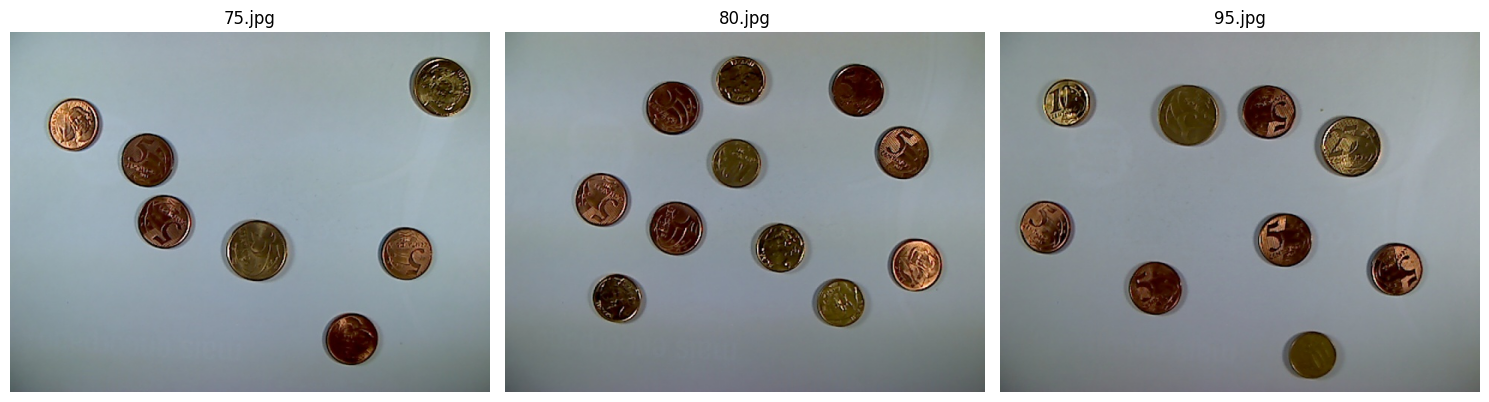

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

for i, file in enumerate(filenames):
    axs[i].imshow(mpimg.imread(file))
    axs[i].set_title(file)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

## Etapa 2: Pipeline de Processamento

A seguir, estão as funções que compõem o pipeline.

### 1) Conversão para Escala de Cinza

Transforma a imagem RGB em uma imagem em tons de cinza, facilitando a análise de intensidade. Aqui, utiliza-se o método Luma, que leva em consideração a sensibilidade do olho humano às cores.

Referência: [Luma method](https://en.wikipedia.org/wiki/Luma_(video))

In [27]:
def convert_to_grayscale(img: np.ndarray) -> np.ndarray:
    """
    Converte uma imagem colorida (RGB) para escala de cinza usando a fórmula:
    gray = 0.3*R + 0.59*G + 0.11*B
    """
    return np.uint8(0.3*img[:,:,0] + 0.59*img[:,:,1] + 0.11*img[:,:,2])

### 2) Segmentação e Pós-processamento Morfológico

Primeiramente, é aplicada a limiarização automática com Otsu, que é uma técnica muito útil para definir automaticamente o limiar utilizado para segmentar os objetos. Essa abordagem espera que a imagem possui 2 picos distintos de intensidade, ou seja, pixels representando a região de interesse, e outros representando o fundo.

Assim, utiliza-se a função `cv2.threshold` para aplicar o método de Otsu, que encontra automaticamente um limiar de separação entre fundo e moedas.

Em seguida, a função `cv2.morphologyEx` aplica operações morfológicas com um elemento estruturante (kernel). Aqui:
  - **Closing**: preenche pequenos buracos e conecta regiões próximas.
  - **Opening**: remove pequenos ruídos isolados.

Referências:
- [Segmentação por Otsu](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/14_Segmentacao_por_Otsu.ipynb)
- [Image Thresholding Using OpenCV](https://opencv.org/image-thresholding-using-opencv/)
- [Image Thresholding Using OpenCV](https://opencv.org/image-thresholding-using-opencv/)

In [28]:
def seg_and_postprocessing(img: np.ndarray, k_cl: int, k_op: int) -> np.ndarray:
    """
    Recebe uma imagem em escala de cinza, aplica segmentação por limiarização usando Otsu.
    Melhora a segmentação aplicando operações morfológicas de fechamento e abertura.
    Retorna a imagem segmentada após as operações morfológicas.
    Args:
        img: A imagem em escala de cinza a ser segmentada.
        k_cl: O tamanho do kernel para a operação de fechamento.
        k_op: O tamanho do kernel para a operação de abertura.
    """
    # Aplicando segmentação por limiarização usando Otsu
    # https://opencv.org/image-thresholding-using-opencv/
    # A função cv2.threshold possui os seguintes parâmetros:
        # - src: A imagem de entrada em escala de cinza. Aqui, usa-se 255 - img para inverter a imagem.
        # - thresh: O valor do limiar.
        # - maxval: O valor máximo a ser atribuído aos pixels que satisfazem a condição do limiar.
        # - type: O tipo de limiarização a ser aplicada.
    # Aqui, usamos thresh=0 e type=cv2.THRESH_BINARY+cv2.THRESH_OTSU para que o método determine automaticamente o melhor limiar.
    # Retorna uma tupla:
        # - O primeiro é o valor do limiar encontrado por Otsu.
        # - O segundo é a imagem binarizada resultante da aplicação do limiar.
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    # Aplicando as operações morfológicas de fechamento e abertura
    kernel_cl = np.ones((k_cl, k_cl), np.uint8)
    kernel_op = np.ones((k_op, k_op), np.uint8)
    # closing: preenche pequenos buracos na região segmentada, conectando áreas próximas.
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    # opening: remove pequenos objetos ou ruídos.
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    # Visualizando as imagens intermediárias e final
    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.title('Segmentação por Otsu')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.title('Fechamento')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.title('Abertura')
    plt.axis('off')
    plt.show()

    return open

### 3) Obtenção de Componentes Conexos

Nesta etapa, usamos `cv2.connectedComponentsWithStats` para identificar cada moeda como uma região conectada na imagem binária.

Neste notebook, usamos `connectivity=4`, que considera conexão apenas por vizinhos horizontais e verticais.

A função retorna:

- `retval`: número de rótulos encontrados, incluindo o fundo.
- `labels`: é a imagem de rótulos, onde cada pixel tem um valor correspondente ao rótulo da região a que pertence.
- `stats`: é uma matriz de estatísticas para cada rótulo
- `centroids`: é uma matriz de coordenadas dos centróides para cada rótulo.


**Referência**: [OpenCV Connected Component Labeling and Analysis](https://pyimagesearch.com/2021/02/22/opencv-connected-component-labeling-and-analysis/)

In [29]:
def get_connected_components(img: np.ndarray, connectivity: int = 4) -> tuple:
    """
    Aplica a função cv2.connectedComponentsWithStats para rotular as regiões conectadas na imagem segmentada.
    https://pyimagesearch.com/2021/02/22/opencv-connected-component-labeling-and-analysis/
    Args:
        img: A imagem segmentada (binária) onde as regiões conectadas serão rotuladas.
        connectivity: O tipo de conectividade a ser usada para determinar as regiões conectadas.
    Returns:
        Uma tupla contendo: retval, labels, stats, centroids.
    """
    return cv2.connectedComponentsWithStats(img, connectivity)

### 4) Cálculo de Áreas dos Componentes

Esta função calcula o número de pixels (área) de cada componente conexo (cada moeda) encontrado na imagem segmentada.

In [30]:
def calc_npixels_label(img, n_labels):
    """
    Calcula o número de pixels para cada rótulo presente na imagem segmentada.
    Args:
        img: Imagem segmentada, onde cada pixel tem um valor correspondente ao rótulo da região a que pertence.
        n_labels: Número total de rótulos presentes na imagem segmentada.
    Returns:
        Uma lista contendo o número de pixels para cada rótulo.
    """
    list_npixels = []
    # Para cada rótulo, calcula o número de pixels que pertencem a esse rótulo.
    # Exceto o rótulo 0, que geralmente representa o fundo.
    # A expressão img[img == v+1] cria um array contendo apenas os pixels que pertencem ao rótulo v+1.
    # Dividindo por (v+1) e somando os valores, obtemos o número de pixels que pertencem a esse rótulo.
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

### 5) Classificação das Moedas

Após calcular a área de cada componente, classificamos a moeda por faixas de pixels:
- `n_pixels < 3500`: 10 centavos
- `3500 <= n_pixels <= 4600`: 5 centavos
- `n_pixels > 4600`: 25 centavos

Esses limiares foram ajustados empiricamente para este conjunto de imagens.

In [31]:
def classify_coin(n_pixels: int) -> int:
    """
    Classifica as moedas com base no número de pixels (área) de cada rótulo.
    Args:
        n_pixels: Número de pixels para o rótulo atual.
    Returns:
        Uma lista de strings com a classificação de cada moeda.
    """
    if n_pixels < 3500:
        return 10   # 10 centavos
    elif n_pixels > 4600:
        return 25   # 25 centavos
    else:
        return 5    # 5 centavos

### Processamento completo

In [32]:
def process(filename):
    # 1) Lendo a imagem e convertendo para escala de cinza
    img = mpimg.imread(file).astype('uint8')
    img_gray = convert_to_grayscale(img)

    # 2) Aplicando segmentação e pós-processamento morfológico
    seg_img = seg_and_postprocessing(img_gray, 15, 31)

    # 3) Obtendo componentes conectados da imagem segmentada
    output = get_connected_components(seg_img, 4)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(output[1])
    plt.title('Imagem segmentada rotulada')
    plt.axis('off')

    # 4) Calcula o número de pixels para cada rótulo presente na imagem segmentada, excluindo o fundo (rótulo 0).
    # Em outras palavras, calcula a área de cada região segmentada (moeda).
    list_npixels = calc_npixels_label(output[1], output[0])

    # 5) Para cada rótulo, verifica o número de pixels e atribui um valor monetário com base nesse número.
    sum = 0
    for n, p in enumerate(list_npixels):
        # Obtém as coordenadas do centróide da região segmentada correspondente ao rótulo atual.
        x = int(output[3][n+1][0])
        y = int(output[3][n+1][1])
        # Classifica a moeda com base no número de pixels e acumula o valor total.
        value = classify_coin(p)
        sum += value
        # Insere o valor da moeda na imagem original, próximo ao centróide da região segmentada.
        cv2.putText(img, str(value), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Imagem com classificação das moedas')
    plt.show()

    print('Imagem', file)
    print('Número de moedas', len(list_npixels))
    print(list_npixels)
    print('Valor total:', sum)
    print()

## Etapa 3: Processamento em Todas as Imagens

Aplicamos o pipeline completo para cada uma das imagens de teste, exibindo os resultados de segmentação, contagem e classificação de moedas.

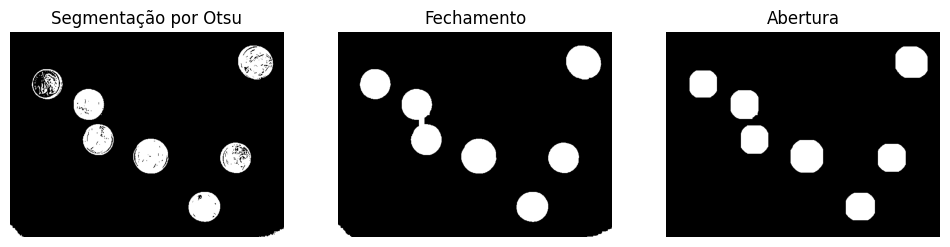

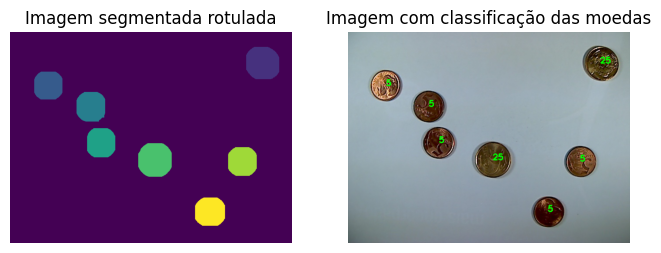

Imagem 75.jpg
Número de moedas 7
[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Valor total: 75



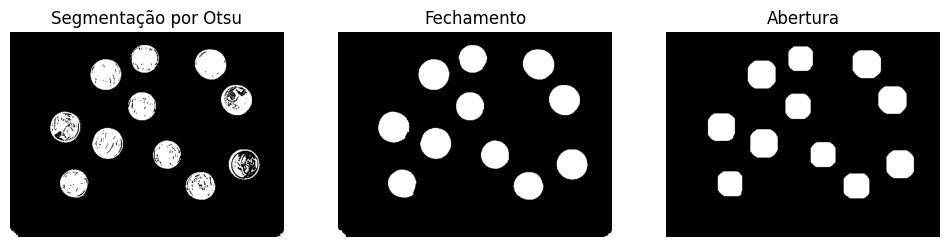

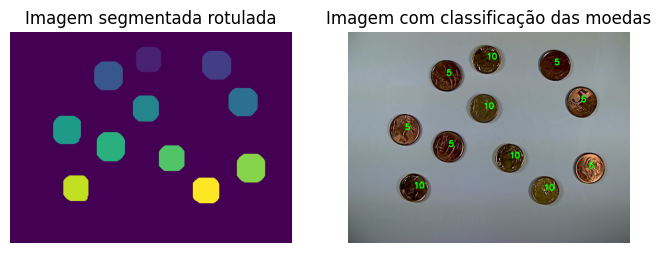

Imagem 80.jpg
Número de moedas 11
[np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Valor total: 80



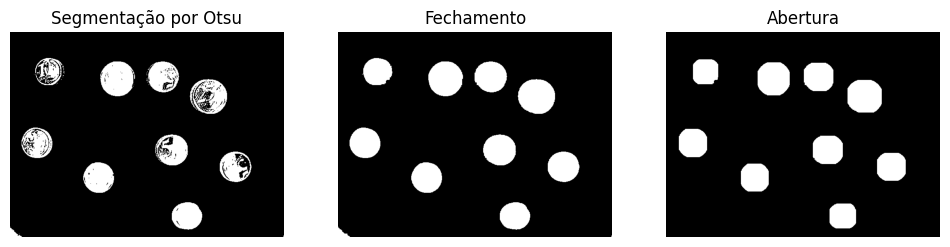

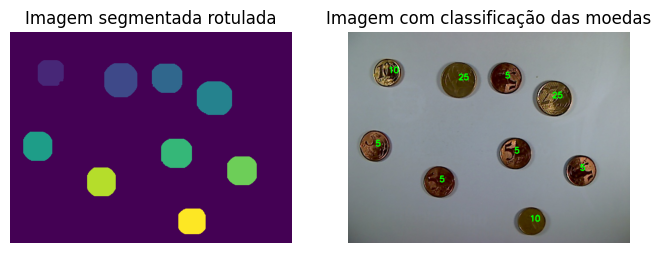

Imagem 95.jpg
Número de moedas 9
[np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Valor total: 95



In [33]:
for file in filenames:
    process(file)